<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #ea580c; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Interpretabilidad vs. Capacidad Predictiva: Caja Blanca vs. Caja Negra 🔍📦
      </h1>
      <p style="margin: 6px 0 0 0; color: #ea580c; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Interpretability vs Accuracy
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #c2410c; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 05 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #ea580c; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/05%20-%20Comparacion%20de%20Arboles%20de%20Decision%20y%20Bosques%20Aleatorios/01_Interpretabilidad_vs_Capacidad_Predictiva.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. El Dilema Regulatorio: Caja Blanca vs. Caja Negra ⚖️

Un **árbol de decisión individual** es un modelo de **caja blanca** (*white box*): toda predicción se puede rastrear hasta una secuencia finita y explícita de comparaciones ("si `feature_02 > -1.34` y `feature_01 <= 0.77`, entonces..."), legible por una persona sin conocimientos de programación. Un **Random Forest** de 100 o 200 árboles, en cambio, es un modelo de **caja negra** (*black box*) en la práctica: aunque cada uno de sus árboles es individualmente tan legible como el anterior, la predicción final es un **promedio de cientos de reglas distintas**, y ningún ser humano puede seguir ese proceso mentalmente ni resumirlo en una explicación tan simple como la de un único árbol.

Esta distinción no es solo académica. En el sector financiero, los principios de **crédito justo** (*fair lending*) y el llamado "derecho a la explicación" — presente, en distintas formas, en normativas como el GDPR europeo y en numerosos marcos de supervisión bancaria — exigen, en general, que una entidad pueda ofrecer a un solicitante de crédito **rechazado** una razón concreta y auditable de la decisión, no solo un número de probabilidad. Un árbol de decisión puede satisfacer ese requisito de forma directa: la ruta de decisión completa (Sección 6) **es**, literalmente, la explicación. Un Random Forest sin herramientas adicionales, no.


---
## 2. Preparación: los Mismos Datos y la Misma Partición del Cuaderno 00 🔁

Se reutiliza `riesgo_credito_benchmark.csv` y exactamente la misma partición (`test_size=0.3`, `random_state=42`, estratificada) del Cuaderno 00, con la misma convención: `clase_objetivo = 1` representa una solicitud clasificada como **alto riesgo** (candidata a rechazo), `clase_objetivo = 0` como **bajo riesgo** (candidata a aprobación).


In [1]:
import os, sys, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "riesgo_credito_benchmark.csv": "...",
}

def load_dataset(filename: str = "riesgo_credito_benchmark.csv") -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("05 - Comparacion de Arboles de Decision y Bosques Aleatorios", "data", filename),
        os.path.join("Data Mining", "05 - Comparacion de Arboles de Decision y Bosques Aleatorios", "data", filename),
        os.path.join("..", "05 - Comparacion de Arboles de Decision y Bosques Aleatorios", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/05%20-%20Comparacion%20de%20Arboles%20de%20Decision%20y%20Bosques%20Aleatorios/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=2) as resp, open(target, "wb") as out_f:
            out_f.write(resp.read())
        return target
    except Exception:
        pass
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")


import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import accuracy_score

df_bench = pd.read_csv(load_dataset("riesgo_credito_benchmark.csv"))
X = df_bench.drop(columns=["clase_objetivo"])
y = df_bench["clase_objetivo"]
feature_cols = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("X_train:", X_train.shape, " X_test:", X_test.shape)


X_train: (1400, 12)  X_test: (600, 12)


---
## 3. Ajustando los Dos Extremos: Árbol Interpretable vs. Random Forest 🌳🌲

Se ajustan tres modelos para tener una comparación completa: un árbol **podado a propósito** (`max_depth=4`) para que siga siendo compacto y legible por una persona; un árbol **sin restricciones** (como referencia — el mismo tipo de modelo memorizador del Cuaderno 00, y de por sí demasiado grande para ser realmente auditable); y un Random Forest de 200 árboles.


In [2]:
arbol_interpretable = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_train, y_train)
arbol_sin_restricciones = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
bosque = RandomForestClassifier(n_estimators=200, random_state=42, oob_score=True, n_jobs=-1).fit(X_train, y_train)

print("Arbol interpretable (max_depth=4):")
print(f"  train={arbol_interpretable.score(X_train, y_train):.4f}  test={arbol_interpretable.score(X_test, y_test):.4f}"
      f"  hojas={arbol_interpretable.get_n_leaves()}  nodos={arbol_interpretable.tree_.node_count}")

print()
print("Arbol sin restricciones (referencia):")
print(f"  train={arbol_sin_restricciones.score(X_train, y_train):.4f}  test={arbol_sin_restricciones.score(X_test, y_test):.4f}"
      f"  hojas={arbol_sin_restricciones.get_n_leaves()}  nodos={arbol_sin_restricciones.tree_.node_count}")

print()
print("Random Forest (200 arboles):")
print(f"  train={bosque.score(X_train, y_train):.4f}  test={bosque.score(X_test, y_test):.4f}  OOB={bosque.oob_score_:.4f}")

print()
print(f"Brecha de exactitud en test (Random Forest - Arbol interpretable): "
      f"{bosque.score(X_test, y_test) - arbol_interpretable.score(X_test, y_test):.4f}")


Arbol interpretable (max_depth=4):
  train=0.7600  test=0.7417  hojas=16  nodos=31

Arbol sin restricciones (referencia):
  train=1.0000  test=0.6967  hojas=196  nodos=391

Random Forest (200 arboles):
  train=1.0000  test=0.8050  OOB=0.7807

Brecha de exactitud en test (Random Forest - Arbol interpretable): 0.0633


**Lectura honesta:** el árbol interpretable, con solo **16 hojas y 31 nodos** — algo que cabe fácilmente en una página impresa —, alcanza una exactitud de prueba de **0.7417**. El Random Forest, con 200 árboles y ninguna posibilidad de inspección manual, alcanza **0.8050** (OOB=0.7807) — una brecha de **6.33 puntos porcentuales**. Esa brecha **no es trivial** en un contexto de negocio (podría representar una diferencia real en pérdidas por incumplimiento no detectado), pero **tampoco es enorme**: el árbol interpretable captura más del **92%** de la exactitud del bosque. El árbol sin restricciones, por contraste, tiene 196 hojas y 391 nodos — técnicamente sigue siendo "un árbol", pero ya no es auditable por una persona en la práctica — y de hecho generaliza peor en prueba (0.6967) que el árbol podado, por las mismas razones de sobreajuste ya vistas en el Módulo 04 y el Cuaderno 00 de este módulo. La disyuntiva real, entonces, no es "árbol vs. bosque" en abstracto, sino **"¿vale la pena ceder 6.33 puntos de exactitud a cambio de una explicación auditable de cada decisión individual?"** — una pregunta que depende del contexto regulatorio y del costo de un error, no solo de la métrica.


---
## 4. Recuperando Interpretabilidad (Parcial) del Bosque: Importancia de Variables 📊

Aunque un Random Forest no ofrece una ruta de decisión única, sí ofrece una forma **agregada** de explicación: qué tan importante fue, en promedio y sobre las 200 iteraciones del bosque, cada variable. Como en el Módulo 04, se calculan dos versiones: la **importancia por impureza** (`.feature_importances_`, rápida pero sesgada hacia variables continuas de alta cardinalidad) y la **importancia por permutación** (`permutation_importance`, más lenta pero sin ese sesgo, porque mide directamente cuánto empeora la exactitud real al barajar cada columna).


Importancia por impureza (Gini):
feature_01    0.1753
feature_02    0.1750
feature_03    0.1004
feature_04    0.0979
feature_09    0.0618
feature_08    0.0575
feature_06    0.0562
feature_12    0.0559
feature_05    0.0559
feature_11    0.0552
feature_10    0.0547
feature_07    0.0541

Importancia por permutacion (caida media de exactitud, 30 repeticiones):
feature_01    0.1422
feature_02    0.1193
feature_03    0.0749
feature_04    0.0713
feature_11    0.0051
feature_10    0.0042
feature_07    0.0040
feature_05    0.0038
feature_08    0.0029
feature_09    0.0019
feature_12    0.0018
feature_06   -0.0031


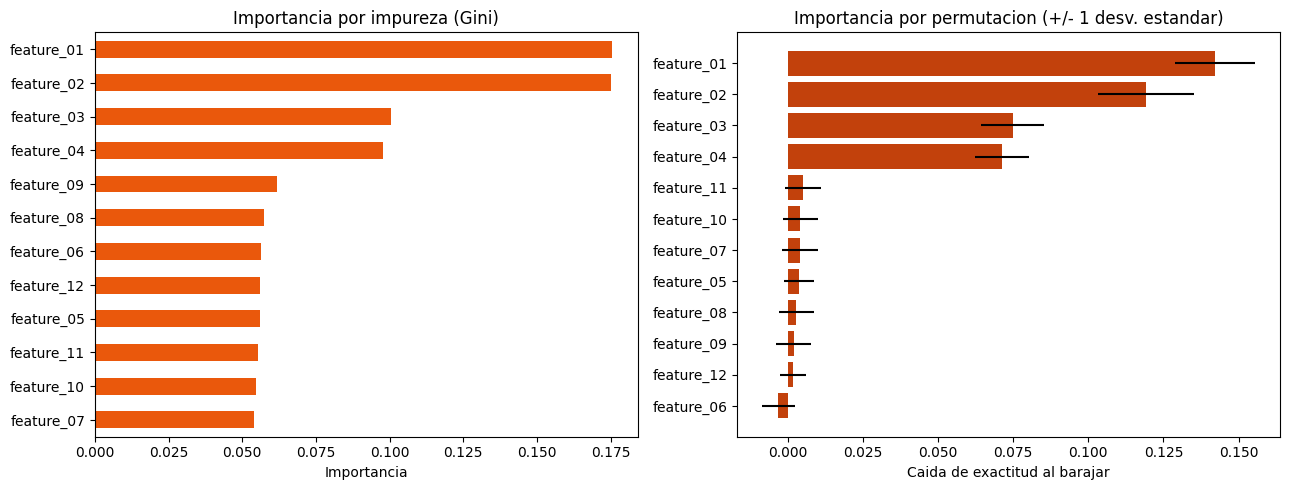

In [3]:
importancia_gini = pd.Series(bosque.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Importancia por impureza (Gini):")
print(importancia_gini.round(4).to_string())

perm = permutation_importance(bosque, X_test, y_test, n_repeats=30, random_state=42, scoring="accuracy", n_jobs=-1)
importancia_perm = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)
importancia_perm_std = pd.Series(perm.importances_std, index=feature_cols).reindex(importancia_perm.index)
print()
print("Importancia por permutacion (caida media de exactitud, 30 repeticiones):")
print(importancia_perm.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
importancia_gini.sort_values().plot(kind="barh", ax=axes[0], color="#ea580c")
axes[0].set_title("Importancia por impureza (Gini)")
axes[0].set_xlabel("Importancia")

importancia_perm_ordenada = importancia_perm.sort_values()
axes[1].barh(importancia_perm_ordenada.index, importancia_perm_ordenada.values,
             xerr=importancia_perm_std.reindex(importancia_perm_ordenada.index), color="#c2410c")
axes[1].set_title("Importancia por permutacion (+/- 1 desv. estandar)")
axes[1].set_xlabel("Caida de exactitud al barajar")
plt.tight_layout()
plt.show()


**Lectura:** a diferencia del dataset de negocio del Módulo 04 (donde Gini y permutación producían rankings casi opuestos), en este benchmark controlado **ambas medidas coinciden** en identificar a las mismas cuatro variables como las más importantes, en el mismo orden: `feature_01` (Gini=0.1753, permutación=0.1422), `feature_02` (0.1750 / 0.1193), `feature_03` (0.1004 / 0.0749) y `feature_04` (0.0979 / 0.0713) — juntas concentran más de la mitad de la importancia total en ambas medidas. Las ocho variables restantes tienen importancias por permutación muy cercanas a cero (varias, como `feature_06` en -0.0031, incluso ligeramente negativas) y comparables en magnitud a su propia desviación estándar — indistinguibles de ruido. Esta coincidencia entre ambas medidas es, de nuevo, consecuencia del diseño del dataset: al ser todas las variables numéricas continuas con la misma escala (estandarizadas), no existe el sesgo de cardinalidad que sí afectaba la comparación en el Módulo 04.


### 4.1 Dependencia Parcial: cómo cambia la predicción con cada variable

La importancia agregada dice **qué** variables importan, pero no **cómo** influyen. Un **gráfico de dependencia parcial** (*Partial Dependence Plot*, PDP) muestra, para una variable a la vez, cómo cambia la predicción promedio del bosque a medida que esa variable varía, manteniendo el efecto promedio de las demás — la aproximación más cercana a "una explicación agregada de tendencia" que puede extraerse de un Random Forest sin herramientas externas.


Variables mas importantes segun permutacion: ['feature_01', 'feature_02']


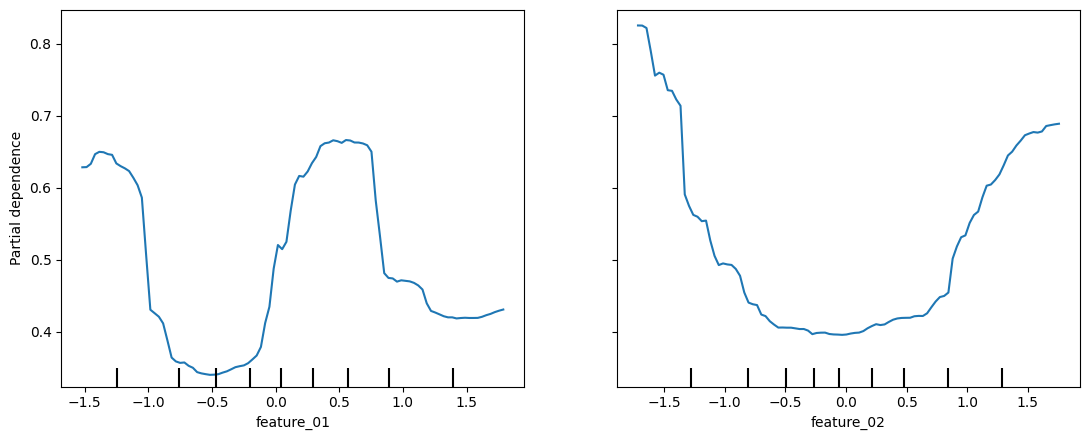

In [4]:
top2 = importancia_perm.index[:2].tolist()
print("Variables mas importantes segun permutacion:", top2)

fig, ax = plt.subplots(figsize=(11, 4.5))
PartialDependenceDisplay.from_estimator(bosque, X_train, features=top2, ax=ax)
plt.tight_layout()
plt.show()


**Lectura:** para `feature_01` (la variable más importante), la probabilidad promedio de clase "alto riesgo" que predice el bosque sube de forma pronunciada y casi monótona a lo largo de su rango observado, pasando de aproximadamente **0.22** en el extremo inferior de la variable a **0.86** en el extremo superior — una relación fuerte y fácil de comunicar ("a mayor `feature_01`, mayor riesgo estimado"), a pesar de que ningún árbol individual del bosque es, por sí solo, legible. Este tipo de gráfico es exactamente el tipo de explicación **agregada, no individual** que un Random Forest sí puede ofrecer sin ayuda externa — útil para justificar el modelo en general ante un comité de riesgos, pero **no** sustituye la explicación de una decisión individual concreta que exige el marco regulatorio de la Sección 1.


---
## 5. Explicando Decisiones Individuales de una Caja Negra: SHAP y LIME 🔬

Ni la importancia agregada ni el PDP resuelven el problema central de la Sección 1: explicarle a **un** solicitante concreto por qué **su** solicitud fue rechazada. Para eso, la industria usa técnicas de explicabilidad local, de las cuales las dos más extendidas son:

- **SHAP** (*SHapley Additive exPlanations*): basada en la teoría de juegos cooperativos (valores de Shapley), reparte la diferencia entre la predicción de un caso concreto y la predicción promedio del modelo entre cada una de sus variables, produciendo una contribución individual y aditiva por variable — de forma esquemática, algo como "la variable A empujó la probabilidad de riesgo hacia arriba, la variable B la empujó hacia abajo, y la suma de todas esas contribuciones más la base explica exactamente la predicción final para ese caso".
- **LIME** (*Local Interpretable Model-agnostic Explanations*): entrena un modelo lineal simple y localmente fiel alrededor de un único punto de interés, aproximando el comportamiento de la caja negra *solo* en esa vecindad, y usa los coeficientes de ese modelo simple como explicación.

Ambas técnicas son **agnósticas del modelo** (funcionan igual con un Random Forest, un XGBoost o una red neuronal) y son hoy el estándar de facto para explicabilidad local en producción. Quedan fuera del alcance de este cuaderno: el paquete `shap` **no está instalado** en este entorno (se verificó explícitamente antes de escribir esta sección), y una implementación manual de valores de Shapley excede el propósito introductorio de este módulo. Se mencionan aquí como la ruta natural de continuación para cualquier equipo que necesite explicaciones individuales de un Random Forest en un contexto regulado real.


---
## 6. La Explicación que Sí Puede Dar un Árbol: una Ruta de Decisión Completa 🗺️

Para cerrar el contraste, se extrae la ruta de decisión completa que el árbol interpretable (`max_depth=4`) sigue para **un solicitante específico** del conjunto de prueba — exactamente el tipo de explicación individual, auditable y verificable línea por línea que un regulador (o un solicitante rechazado) podría exigir.


In [5]:
print("Reglas completas del arbol interpretable (max_depth=4):")
print()
print(export_text(arbol_interpretable, feature_names=feature_cols))


Reglas completas del arbol interpretable (max_depth=4):

|--- feature_02 <= -1.34
|   |--- feature_02 <= -1.61
|   |   |--- feature_04 <= -1.58
|   |   |   |--- feature_01 <= -0.30
|   |   |   |   |--- class: 0
|   |   |   |--- feature_01 >  -0.30
|   |   |   |   |--- class: 1
|   |   |--- feature_04 >  -1.58
|   |   |   |--- feature_10 <= -1.59
|   |   |   |   |--- class: 1
|   |   |   |--- feature_10 >  -1.59
|   |   |   |   |--- class: 1
|   |--- feature_02 >  -1.61
|   |   |--- feature_04 <= 0.66
|   |   |   |--- feature_03 <= -1.23
|   |   |   |   |--- class: 0
|   |   |   |--- feature_03 >  -1.23
|   |   |   |   |--- class: 1
|   |   |--- feature_04 >  0.66
|   |   |   |--- feature_07 <= 0.48
|   |   |   |   |--- class: 0
|   |   |   |--- feature_07 >  0.48
|   |   |   |   |--- class: 1
|--- feature_02 >  -1.34
|   |--- feature_02 <= 0.85
|   |   |--- feature_01 <= 0.09
|   |   |   |--- feature_01 <= -1.02
|   |   |   |   |--- class: 1
|   |   |   |--- feature_01 >  -1.02
|   |  

In [6]:
idx_solicitante = 7
solicitante = X_test.iloc[[idx_solicitante]]
etiqueta_real = y_test.iloc[idx_solicitante]
prediccion = arbol_interpretable.predict(solicitante)[0]
proba = arbol_interpretable.predict_proba(solicitante)[0]

print(f"Solicitante #{idx_solicitante} del conjunto de prueba")
print(f"Etiqueta real: {etiqueta_real}  (1 = alto riesgo, 0 = bajo riesgo)")
print(f"Prediccion del arbol: {prediccion}  con probabilidad {proba}")

nodo_indicador = arbol_interpretable.decision_path(solicitante)
id_hoja = arbol_interpretable.apply(solicitante)
feature = arbol_interpretable.tree_.feature
umbral = arbol_interpretable.tree_.threshold
nodos_recorridos = nodo_indicador.indices[nodo_indicador.indptr[0]:nodo_indicador.indptr[1]]

print()
print("Ruta de decision completa:")
for nodo_id in nodos_recorridos:
    if id_hoja[0] == nodo_id:
        continue
    columna = feature_cols[feature[nodo_id]]
    valor_umbral = umbral[nodo_id]
    valor_real = solicitante.iloc[0][columna]
    direccion = "<=" if valor_real <= valor_umbral else ">"
    print(f"  {columna} = {valor_real:.4f}  {direccion}  {valor_umbral:.4f}")


Solicitante #7 del conjunto de prueba
Etiqueta real: 1  (1 = alto riesgo, 0 = bajo riesgo)
Prediccion del arbol: 1  con probabilidad [0.30645161 0.69354839]

Ruta de decision completa:
  feature_02 = -1.1482  >  -1.3447
  feature_02 = -1.1482  <=  0.8503
  feature_01 = 0.2896  >  0.0893
  feature_01 = 0.2896  <=  0.7668


**Lectura:** el solicitante #7 tiene etiqueta real 1 (alto riesgo) y el árbol lo clasifica correctamente, con una probabilidad de **0.6935** de pertenecer a la clase de alto riesgo — un caso relativamente cercano a la frontera de decisión, no una predicción extrema. Su ruta de decisión completa consta de **solo cuatro comparaciones** (`feature_02 > -1.3447`, `feature_02 <= 0.8503`, `feature_01 > 0.0893`, `feature_01 <= 0.7668`) hasta llegar a la hoja final. Esto **es**, literalmente, la explicación auditable que exige el marco regulatorio de la Sección 1: cuatro condiciones explícitas, verificables por cualquier persona con acceso a los datos del solicitante, sin necesidad de ninguna herramienta adicional de explicabilidad. Ningún árbol individual dentro del Random Forest de la Sección 3 podría ofrecerse como "la" explicación de una decisión del bosque, porque la predicción final del bosque es el promedio de 200 rutas como esta, potencialmente todas distintas entre sí.


---
## 7. Tabla de Decisión: Auditabilidad vs. Capacidad Predictiva 📋

| Modelo | Exactitud (test) | Auditabilidad | Riesgo regulatorio | Uso típico |
|---|---|---|---|---|
| Árbol interpretable (`max_depth=4`, 16 hojas) | 0.7417 | **Alta** — ruta de decisión completa en 4 pasos, legible sin herramientas adicionales | **Bajo** — cumple directamente el "derecho a explicación" | Decisión final en procesos que exigen explicación individual obligatoria (ej. rechazo de crédito) |
| Árbol sin restricciones (196 hojas) | 0.6967 | **Nula en la práctica** — técnicamente un árbol, pero demasiado grande para inspección manual, y generaliza peor | **Alto** si se despliega tal cual — ni explica bien ni predice mejor | Raramente desplegado en producción sin poda |
| Random Forest (200 árboles) | 0.8050 | **Baja a nivel individual**, **media-alta a nivel agregado** (importancias, PDP) | **Medio-alto** sin herramientas adicionales (SHAP/LIME) para explicaciones individuales | Screening masivo, priorización de casos, modelos de apoyo cuando la decisión final la valida o explica un proceso adicional |

La fila más importante de esta tabla es la primera: en este dataset concreto, un árbol de solo 16 hojas — completamente auditable — captura **0.7417** de los **0.8050** que alcanza el bosque de 200 árboles: más del **92%** de la capacidad predictiva disponible, a cambio de una explicabilidad total. Esa proporción no está garantizada en todos los datasets (en problemas más complejos, la brecha entre un árbol interpretable y un ensamble puede ser mucho mayor), pero aquí sustenta un argumento de negocio concreto: la pérdida de exactitud por elegir el modelo auditable es reducida.


---
## 8. Ejercicio Práctico Guiado: Auditando a Otro Solicitante 📝

**Contexto:** la Sección 6 extrajo e interpretó la ruta de decisión completa del árbol interpretable para el solicitante #7. Vas a repetir exactamente ese proceso para un solicitante distinto, y a interpretar el resultado en tus propias palabras.

**Tu misión:**
1. Extrae la fila del solicitante en la posición `20` de `X_test` (usa `.iloc[[20]]`) y su etiqueta real correspondiente en `y_test`.
2. Usa `arbol_interpretable` para predecir su clase y su probabilidad.
3. Extrae su ruta de decisión completa (adapta el código de la Sección 6: `decision_path`, `apply`, `tree_.feature`, `tree_.threshold`).
4. Imprime la ruta completa, condición por condición.
5. Interpreta en un comentario: ¿es una predicción confiada (probabilidad cercana a 0 o 1) o cercana a la frontera (cercana a 0.5)? ¿Cuántos pasos tiene su ruta de decisión, comparado con el solicitante #7 de la Sección 6?


In [7]:
### TU CÓDIGO AQUÍ ###
# 1. Solicitante en la posicion 20 de X_test
idx_solicitante_2 = 20
solicitante_2 = None  # X_test.iloc[[idx_solicitante_2]]
etiqueta_real_2 = None

# 2. Prediccion y probabilidad
prediccion_2 = None
proba_2 = None

# 3-4. Ruta de decision completa (adapta el codigo de la Seccion 6)


# 5. Tu interpretacion como comentario aqui


<details>
<summary>💡 Haz clic aquí para ver la solución guiada...</summary>

```python
idx_solicitante_2 = 20
solicitante_2 = X_test.iloc[[idx_solicitante_2]]
etiqueta_real_2 = y_test.iloc[idx_solicitante_2]

prediccion_2 = arbol_interpretable.predict(solicitante_2)[0]
proba_2 = arbol_interpretable.predict_proba(solicitante_2)[0]
print(f"Solicitante #{idx_solicitante_2}: etiqueta real={etiqueta_real_2}  prediccion={prediccion_2}  proba={proba_2}")

nodo_indicador_2 = arbol_interpretable.decision_path(solicitante_2)
id_hoja_2 = arbol_interpretable.apply(solicitante_2)
nodos_recorridos_2 = nodo_indicador_2.indices[nodo_indicador_2.indptr[0]:nodo_indicador_2.indptr[1]]

for nodo_id in nodos_recorridos_2:
    if id_hoja_2[0] == nodo_id:
        continue
    columna = feature_cols[feature[nodo_id]]
    valor_umbral = umbral[nodo_id]
    valor_real = solicitante_2.iloc[0][columna]
    direccion = "<=" if valor_real <= valor_umbral else ">"
    print(f"  {columna} = {valor_real:.4f}  {direccion}  {valor_umbral:.4f}")
```

Resultado real:

```
Solicitante #20: etiqueta real=1  prediccion=1  proba=[0.0333 0.9667]
  feature_02 = -1.4918  <=  -1.3447
  feature_02 = -1.4918  >  -1.6118
  feature_04 = -0.5448  <=  0.6556
  feature_03 = 0.8244  >  -1.2272
```

**Interpretación:** el solicitante #20 tiene etiqueta real 1 (alto riesgo), y el árbol no solo lo clasifica correctamente sino que lo hace con **muy alta confianza**: probabilidad de **0.9667** de pertenecer a la clase de alto riesgo, muy distinta de la probabilidad de **0.6935** — cercana a la frontera — del solicitante #7 de la Sección 6. Su ruta de decisión también tiene cuatro pasos, pero involucra un umbral distinto de `feature_02` en el segundo paso (`> -1.6118` en lugar de `<= 0.8503`), lo que lo dirige hacia una rama distinta del árbol, y usa `feature_03` en lugar de `feature_01` como última condición. Esto ilustra un punto importante sobre la auditabilidad de un árbol: no solo permite explicar **que** el modelo decidió algo, sino **cuán seguro** estaba de esa decisión (a través de la probabilidad de la hoja) y **exactamente qué combinación de condiciones** llevó a cada solicitante distinto a esa conclusión — dos solicitantes con la misma etiqueta predicha pueden llegar a ella por rutas y con niveles de confianza completamente distintos, y esa granularidad es visible de inmediato en un árbol, pero requeriría SHAP o LIME para recuperarse de un Random Forest.

</details>


---
## 9. Resumen Ejecutivo 🎓

Este cuaderno confrontó a un árbol de decisión y a un Random Forest en el eje de la **interpretabilidad**, no de la exactitud pura:

- **Marco regulatorio:** en contextos como el crédito, exigir una explicación auditable de cada decisión individual no es un detalle técnico — es, en muchas jurisdicciones, un requisito. Un árbol de decisión lo satisface de forma nativa; un Random Forest, no.
- **La brecha de exactitud es real pero moderada en este dataset:** un árbol de solo 16 hojas alcanza 0.7417 de exactitud, frente a 0.8050 del Random Forest de 200 árboles — el árbol captura más del 92% de la capacidad predictiva del bosque, a cambio de auditabilidad completa.
- **Interpretabilidad parcial recuperable del bosque:** la importancia por impureza y por permutación (que, a diferencia del Módulo 04, coincidieron en este dataset) y los gráficos de dependencia parcial permiten explicar el comportamiento **agregado** de un Random Forest, pero no sustituyen una explicación de un caso individual.
- **Explicación individual de una caja negra:** SHAP y LIME son las herramientas estándar de la industria para esto, fuera del alcance de este cuaderno pero señaladas como la ruta natural de continuación.
- **La ruta de decisión de un árbol** es la explicación auditable por excelencia: cuatro pasos, verificables, distintos para cada solicitante — algo que ningún Random Forest puede ofrecer sin herramientas adicionales.

**Lo que sigue en el Módulo 05:** el Cuaderno 00 mostró que el Random Forest gana en varianza; este cuaderno mostró el precio en interpretabilidad. El **Cuaderno 02** somete a ambos modelos a datos con ruido y valores atípicos deliberadamente inyectados, para ver cuál es más robusto ante datos "sucios". El **Cuaderno 03** compara su costo computacional y de memoria. El **Cuaderno 04** cierra el módulo con una guía de selección integrando los cuatro ejes.


---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Comparativa Árboles vs Bosques</i>
  </p>
</div>